# ✅ Práctica 1 — Solución de referencia (ramo: Automóviles)
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · UNAM

---

> **Documento del profesor.** Es una solución de referencia sobre una cartera de **autos** de ejemplo
> (semilla distinta a la de los equipos). Muestra *cómo* se resuelve toda la práctica y sirve de patrón
> de corrección; los números de cada equipo serán distintos porque su cartera es distinta.

---
## 1. Cargar datos y explorar las variables de interés

In [1]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
np.random.seed(0); plt.rcParams["figure.figsize"] = (8, 3.6)

df = pd.read_parquet("../inputs/cartera_ejemplo_autos.parquet")
print("Pólizas:", len(df), "| Columnas:", len(df.columns))
print("\nVariables que USO en la Práctica 1:")
print("  frecuencia : num_siniestros, exposicion")
print("  severidad  : monto_promedio_siniestro (ground-up)")
print("  póliza     : deducible, suma_asegurada, coaseguro (para transformar)")
print("\nLos factores (edad_conductor, tipo_vehiculo, zona, ...) NO se usan aquí: son para el GLM (P2).")

Pólizas: 30000 | Columnas: 14

Variables que USO en la Práctica 1:
  frecuencia : num_siniestros, exposicion
  severidad  : monto_promedio_siniestro (ground-up)
  póliza     : deducible, suma_asegurada, coaseguro (para transformar)

Los factores (edad_conductor, tipo_vehiculo, zona, ...) NO se usan aquí: son para el GLM (P2).


% de pólizas con siniestro : 22.4%
Exposición total           : 23,985 años-póliza
Severidad (monto_promedio) → media 52,463  mediana 33,338


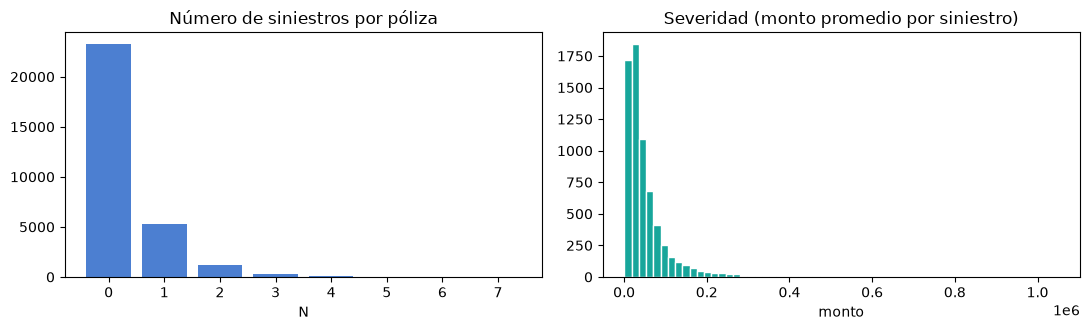

In [2]:
# ─── Exploración enfocada ──────────────────────────────────────────────────
con = df[df.num_siniestros > 0]         # pólizas con al menos un siniestro
print(f"% de pólizas con siniestro : {(df.num_siniestros>0).mean():.1%}")
print(f"Exposición total           : {df.exposicion.sum():,.0f} años-póliza")
print(f"Severidad (monto_promedio) → media {con.monto_promedio_siniestro.mean():,.0f}  "
      f"mediana {con.monto_promedio_siniestro.median():,.0f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(*np.unique(df.num_siniestros, return_counts=True), color="#4C7FD1")
ax[0].set_title("Número de siniestros por póliza"); ax[0].set_xlabel("N")
ax[1].hist(con.monto_promedio_siniestro, bins=60, color="#17A69B", edgecolor="white")
ax[1].set_title("Severidad (monto promedio por siniestro)"); ax[1].set_xlabel("monto")
plt.tight_layout(); plt.show()

---
## 2. Severidad

Ajusto varias distribuciones al `monto_promedio_siniestro` (ground-up) y elijo con **AIC** y la **cola**.

In [3]:
# ─── Ajuste de distribuciones de severidad ─────────────────────────────────
x = con.monto_promedio_siniestro.values
def aic(dist, pr, d): return 2*len(pr) - 2*np.sum(dist.logpdf(d, *pr))
cand = {"Lognormal": stats.lognorm, "Gamma": stats.gamma,
        "Weibull": stats.weibull_min, "Pareto": stats.pareto}
ajustes, filas = {}, []
for nom, dist in cand.items():
    pr = dist.fit(x, floc=0); ajustes[nom] = (dist, pr)
    filas.append({"Distribución": nom, "AIC": round(aic(dist, pr, x), 1)})
tabla = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
mejor = tabla.iloc[0]["Distribución"]
print(tabla.to_string(index=False)); print(f"\n→ Elegida por AIC: {mejor}")

Distribución      AIC
   Lognormal 158618.7
       Gamma 159601.4
     Weibull 159764.4
      Pareto 171687.9

→ Elegida por AIC: Lognormal


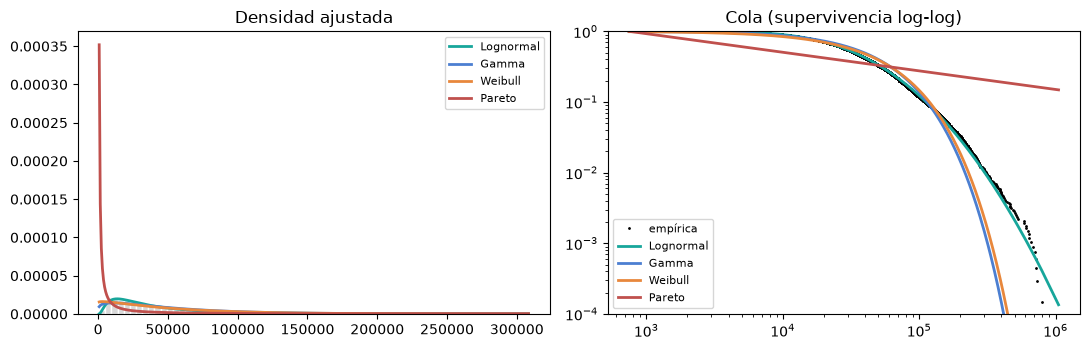

E[X] ground-up (modelo Lognormal) = 52,286


In [4]:
# ─── Diagnóstico de la cola (densidad + supervivencia) ─────────────────────
col = {"Lognormal":"#17A69B","Gamma":"#4C7FD1","Weibull":"#E8873C","Pareto":"#C0504D"}
p99 = np.percentile(x, 99); grid = np.linspace(x.min(), p99, 400)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(x, bins=70, density=True, range=(x.min(), p99), color="#d9d9d9", edgecolor="white")
for nom,(d,pr) in ajustes.items(): ax[0].plot(grid, d.pdf(grid,*pr), color=col[nom], lw=2, label=nom)
ax[0].set_title("Densidad ajustada"); ax[0].legend(fontsize=8)
xs = np.sort(x); S_emp = 1 - np.arange(1,len(xs)+1)/len(xs)
ax[1].plot(xs, S_emp, ".", ms=2, color="black", label="empírica")
for nom,(d,pr) in ajustes.items(): ax[1].plot(xs, d.sf(xs,*pr), color=col[nom], lw=2, label=nom)
ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].set_ylim(1e-4,1)
ax[1].set_title("Cola (supervivencia log-log)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
dist_sev, pr_sev = ajustes[mejor]
print(f"E[X] ground-up (modelo {mejor}) = {dist_sev.mean(*pr_sev):,.0f}")

### Ground-up vs. transformada

La severidad de los datos es **ground-up** (daño real). Lo que **paga la aseguradora** aplica deducible,
coaseguro y límite (suma asegurada). Comparo las dos.

In [5]:
# ─── Severidad que paga la aseguradora (transformada) ──────────────────────
def transformar(x, ded, coas, sa):
    return np.minimum(np.maximum(x - ded, 0) * (1 - coas), sa)

pagado = transformar(con.monto_promedio_siniestro.values,
                     con.deducible.values, con.coaseguro.values, con.suma_asegurada.values)
print(f"E[X] ground-up   : {con.monto_promedio_siniestro.mean():,.0f}")
print(f"E[X] transformada: {pagado.mean():,.0f}")
print(f"La póliza absorbe ~{1 - pagado.mean()/con.monto_promedio_siniestro.mean():.1%} de la severidad "
      f"(sobre todo por el deducible).")

E[X] ground-up   : 52,463
E[X] transformada: 35,195
La póliza absorbe ~32.9% de la severidad (sobre todo por el deducible).


---
## 3. Frecuencia

Ajusto **todas** las opciones con la **exposición como offset**, diagnostico la dispersión y **decido**.

In [6]:
# ─── Poisson, quasi-Poisson y binomial negativa (con offset) ───────────────
y = df.num_siniestros.values
off = np.log(df.exposicion.values)
Xc = np.ones((len(df), 1))

pois  = sm.GLM(y, Xc, family=sm.families.Poisson(), offset=off).fit()
quasi = sm.GLM(y, Xc, family=sm.families.Poisson(), offset=off).fit(scale="X2")
nb    = sm.NegativeBinomial(y, Xc, offset=off).fit(disp=0)

lam_hat = np.exp(pois.params[0])          # tasa por año-póliza
phi = quasi.scale
print(f"Tasa λ̂ (siniestros por año-póliza) = {lam_hat:.4f}")
print(f"Índice de dispersión (Var/media)   = {y.var()/y.mean():.3f}")
print(f"Factor de dispersión φ (quasi)      = {phi:.3f}   (>1 → sobredispersión)")
print(f"\nAIC Poisson           = {pois.aic:,.0f}")
print(f"AIC Binomial negativa = {nb.aic:,.0f}")
print(f"→ Gana: {'Binomial negativa' if nb.aic < pois.aic else 'Poisson'}")

Tasa λ̂ (siniestros por año-póliza) = 0.3583
Índice de dispersión (Var/media)   = 1.266
Factor de dispersión φ (quasi)      = 1.249   (>1 → sobredispersión)

AIC Poisson           = 41,418
AIC Binomial negativa = 40,752
→ Gana: Binomial negativa


P(N=0) observada = 0.776  |  esperada Poisson = 0.752


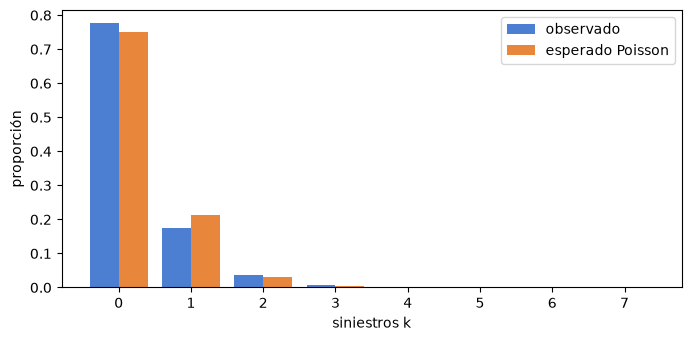

Decisión: hay sobredispersión (φ>1) y la NB baja el AIC → elijo BINOMIAL NEGATIVA.


In [7]:
# ─── Diagnóstico de exceso de ceros + observado vs. esperado ───────────────
mu_i = lam_hat * df.exposicion.values
ceros_obs = (y == 0).mean(); ceros_esp = np.exp(-mu_i).mean()
print(f"P(N=0) observada = {ceros_obs:.3f}  |  esperada Poisson = {ceros_esp:.3f}")

kmax = y.max(); ks = np.arange(0, kmax+1)
obs = np.bincount(y, minlength=kmax+1) / len(y)
esp_pois = np.array([stats.poisson(mu_i).pmf(k) for k in ks]).mean(axis=1)
plt.bar(ks-0.2, obs, width=0.4, color="#4C7FD1", label="observado")
plt.bar(ks+0.2, esp_pois, width=0.4, color="#E8873C", label="esperado Poisson")
plt.xlabel("siniestros k"); plt.ylabel("proporción"); plt.legend(); plt.show()
print("Decisión: hay sobredispersión (φ>1) y la NB baja el AIC → elijo BINOMIAL NEGATIVA.")

---
## 4. Simulación de la pérdida agregada S

Con la severidad elegida y la frecuencia elegida (NB), simulo la **pérdida agregada de la cartera** en
sus dos versiones (ground-up y transformada). Uso la dispersión estimada φ a nivel agregado.

Siniestros esperados en la cartera (Λ) = 8,594

Versión          E[S] (prima pura)           VaR99          TVaR99
Ground-up              449,289,487     468,783,580     471,404,892
Transformada           301,310,807     316,176,067     318,017,117

La póliza (deducible+límite) reduce la prima pura de la cartera un 32.9%: esa es la S que sirve para tarificar el producto.


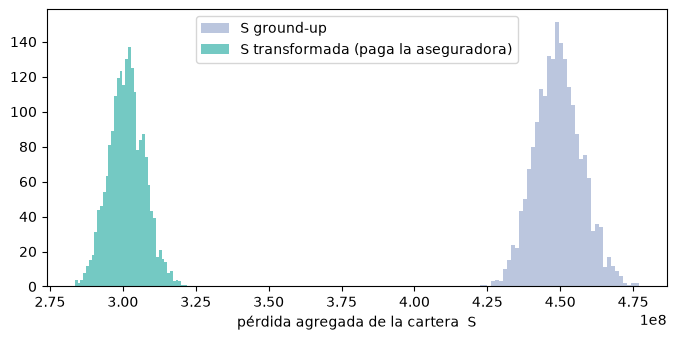

In [8]:
# ─── Simulación del modelo colectivo (ground-up y transformada) ────────────
Lambda = lam_hat * df.exposicion.sum()          # siniestros esperados en la cartera
r_agg  = Lambda / (phi - 1)                      # dispersión agregada (Var = φ·Λ)
p_agg  = r_agg / (r_agg + Lambda)
frecuencia_agg = stats.nbinom(r_agg, p_agg)

ded = df.deducible.values; sa = df.suma_asegurada.values; coas = df.coaseguro.values
M = 2000
Sg = np.empty(M); Sp = np.empty(M)
for m in range(M):
    Ntot = frecuencia_agg.rvs()
    xg = dist_sev.rvs(*pr_sev, size=Ntot)
    pol = np.random.randint(0, len(df), Ntot)
    xp = transformar(xg, ded[pol], coas[pol], sa[pol])
    Sg[m] = xg.sum(); Sp[m] = xp.sum()

def resumen(S):
    v = np.percentile(S, 99); return S.mean(), v, S[S > v].mean()
print(f"Siniestros esperados en la cartera (Λ) = {Lambda:,.0f}\n")
print(f"{'Versión':14}{'E[S] (prima pura)':>20}{'VaR99':>16}{'TVaR99':>16}")
for nom, S in [("Ground-up", Sg), ("Transformada", Sp)]:
    e, v, t = resumen(S)
    print(f"{nom:14}{e:>20,.0f}{v:>16,.0f}{t:>16,.0f}")
print(f"\nLa póliza (deducible+límite) reduce la prima pura de la cartera un "
      f"{1 - Sp.mean()/Sg.mean():.1%}: esa es la S que sirve para tarificar el producto.")

plt.hist(Sg, bins=40, alpha=0.6, color="#8FA0C8", label="S ground-up")
plt.hist(Sp, bins=40, alpha=0.6, color="#17A69B", label="S transformada (paga la aseguradora)")
plt.xlabel("pérdida agregada de la cartera  S"); plt.legend(); plt.show()

> **Lectura del resultado:** a nivel de **toda la cartera** (miles de siniestros), la ley de los grandes
> números hace que S sea muy estable: el VaR99 queda solo ~4–5% por encima de E[S]. Ese porcentaje es,
> justamente, el **recargo de seguridad** que cubriría el percentil 99 de la cartera. El pooling reduce el
> riesgo *relativo* —esa es la esencia del seguro—; la cola pesa mucho más en carteras chicas y en el
> reaseguro (Tema 5).

---
## 5. Validación contra la guía de ramos (Sesión 6)

Contrasto lo obtenido con el perfil de mercado de **autos** de la guía.

In [9]:
# ─── Contraste con el perfil de la guía de ramos ───────────────────────────
print("Guía de ramos (Autos)      vs.   Esta cartera")
print("-" * 55)
print(f"frecuencia: la más alta      →   λ̂ = {lam_hat:.2f}/año-póliza (alta ✓)")
print(f"severidad: moderada          →   media ≈ {con.monto_promedio_siniestro.mean():,.0f} (moderada ✓)")
print(f"cola: media                  →   {mejor} elegida (cola media ✓)")
print(f"frecuencia: Poisson/NB       →   sobredispersión → NB ✓")
print("\nConclusión: la cartera es consistente con el perfil de mercado del ramo.")

Guía de ramos (Autos)      vs.   Esta cartera
-------------------------------------------------------
frecuencia: la más alta      →   λ̂ = 0.36/año-póliza (alta ✓)
severidad: moderada          →   media ≈ 52,463 (moderada ✓)
cola: media                  →   Lognormal elegida (cola media ✓)
frecuencia: Poisson/NB       →   sobredispersión → NB ✓

Conclusión: la cartera es consistente con el perfil de mercado del ramo.


---
## 6. Preguntas de introducción *(ejemplo de respuesta)*

- **¿Por qué el ramo?** Autos es el de mayor frecuencia y penetración del mercado; da mucha
  siniestralidad para modelar y es donde el pricing con GLM tiene más impacto.
- **¿Qué coberturas?** Daños materiales y responsabilidad civil (las de mayor peso en la prima).

## 7. Conclusión

- **Severidad:** lognormal (por AIC y cola). E[X] ground-up ≈ el de la tabla; tras la póliza baja por el deducible.
- **Frecuencia:** binomial negativa (sobredispersión clara, φ>1, menor AIC).
- **Prima pura del producto:** E[S] de la versión **transformada** (la que paga la aseguradora).
- La cartera cuadra con el perfil de autos de la guía de ramos.

*Solución de referencia · Práctica 1 · MASDFR*